
# Dimethyl-Sulfide (DMS) Experiments – Quick-Look Notebook  
# Mas mixing ratio So4(-2) 
### MMrso4
> **Why DMS?**  
> DMS is the dominant natural sulfur source to the marine troposphere and a key precursor for sulfate aerosol and marine cloud brightening.  Understanding how doubling marine DMS emissions changes radiative forcing helps to constrain natural aerosol–cloud feedbacks.
>


Dimethyl sulfide (DMS) emitted by the ocean oxidizes in the atmosphere to sulfuric acid, which nucleates or condenses to form sulfate aerosols (often diagnosed as the mass mixing ratio mmrso4). By comparing a 2×DMS experiment to its piControl, you isolate the effective radiative forcing of that extra DMS via its sulfate burden. Since aerosols concentrate at the surface layer first, we’ll grab only the lowest model level (level = 0 in many CMIP6 AER mon files).
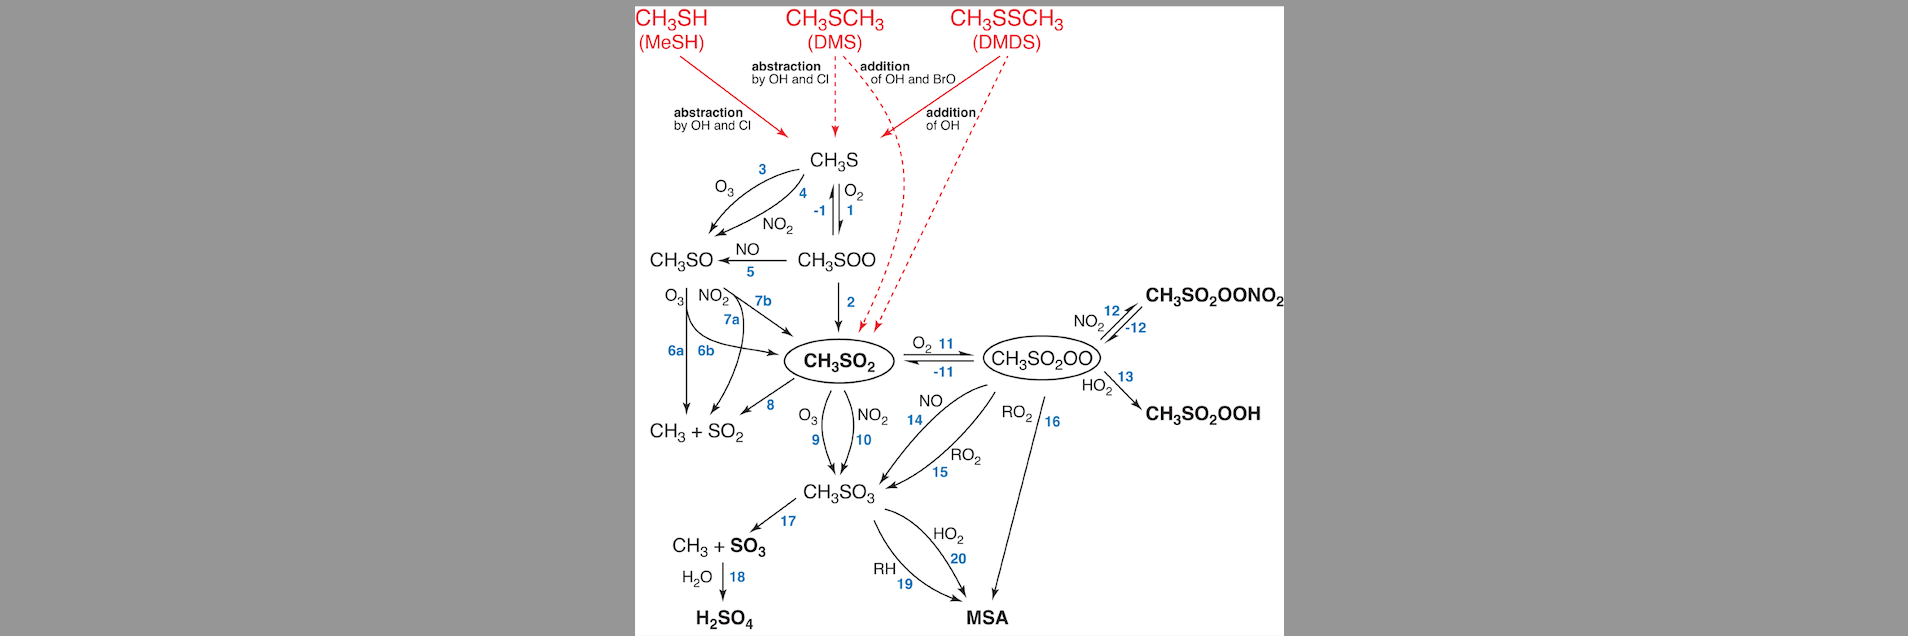

> *Figure 1 –  Gas-phase oxidation scheme for CH₃SCH₃ (DMS) and co-emitted sulfur species.*  Re-drawn after Chen _etal._ (2018) and Barnes _etal._ (2006). 


`DMS emissions` → `gas‐phase oxidation` → `sulfate aerosol mass mixing ratio (mmrso4)` → `cloud/aerosol interactions`  

**In this notebook we will:**

1. Load monthly-mean 4D sulfate aerosol mass mixing ratio (mmrso4) from climate model output.

2. Extract the surface layer (first vertical level) to represent near-surface sulfate concentrations.

3. Time-average over the period of interest to reduce noise.

4. Mask geographically to obtain global, Arctic (lat ≥ 66° N), and Antarctic (lat ≤ –66° S) subsets.

5. Compute area-weighted means using

where we simplify to weights ∝ cos(lat) for regular grids and drop explicit cell-area factors when mapping.

6. Visualize the spatial fields and regional averages to highlight how doubling DMS (2× DMS) changes near‐surface sulfate compared to a piControl run.
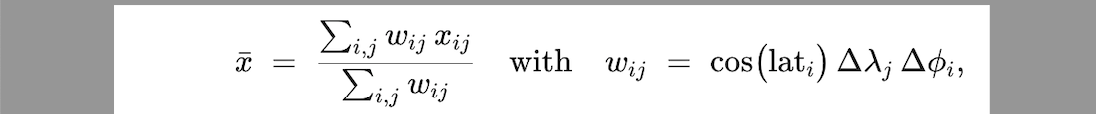

In [2]:
from src.common_imports import *

In [1]:
import sys, pathlib
PROJECT_ROOT = pathlib.Path().resolve().parent        # one level up from notebooks/
if str(PROJECT_ROOT) not in sys.path:                 # avoid duplicates
    sys.path.insert(0, str(PROJECT_ROOT))

In [ ]:
ds = load_cmip6("mmrso4", "piClim-2xDMS_NorESM")

In [6]:
from src.load_data import load_all_data

model_data = load_all_data(
    models   = ["NorESM2-LM"],
    cases    = ["piClim-2xDMS_NorESM", "piClim-control_NorESM"],
    variables=["mmrso4"],
    mock=False,                       # be sure mock mode is off
)

In [7]:
print(model_data['NorESM2-LM']['piClim-control_NorESM'].keys())

dict_keys(['mmrso4'])


In [8]:
print(model_data['NorESM2-LM']['piClim-control_NorESM']['mmrso4'])

<xarray.Dataset> Size: 219MB
Dimensions:    (time: 120, bnds: 2, lev: 32, lat: 96, lon: 144)
Coordinates:
  * time       (time) object 960B 0001-01-16 12:00:00 ... 0010-12-16 12:00:00
  * lev        (lev) float64 256B 0.9926 0.9763 0.9575 ... 0.007595 0.003643
  * lat        (lat) float64 768B -90.0 -88.11 -86.21 ... 86.21 88.11 90.0
  * lon        (lon) float64 1kB 0.0 2.5 5.0 7.5 ... 350.0 352.5 355.0 357.5
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) object 2kB ...
    lev_bnds   (lev, bnds) float64 512B ...
    p0         float64 8B ...
    a          (lev) float64 256B ...
    b          (lev) float64 256B ...
    ps         (time, lat, lon) float32 7MB ...
    a_bnds     (lev, bnds) float64 512B ...
    b_bnds     (lev, bnds) float64 512B ...
    lat_bnds   (lat, bnds) float64 2kB ...
    lon_bnds   (lon, bnds) float64 2kB ...
    mmrso4     (time, lev, lat, lon) float32 212MB ...
Attributes: (12/49)
    Conventions:               CF-1.7 CMIP-6

In [9]:
md = model_data["NorESM2-LM"]                 # convenience alias
md["2xDMS"]  = md.pop("piClim-2xDMS_NorESM")  # rename key
md["control"] = md.pop("piClim-control_NorESM")


In [10]:
from src.analyze_erf_emidms_siconc import analyze_mmrso4
from src.analyze_erf_emidms_siconc import print_results
mmrso4_results, mmrso4_data = analyze_mmrso4(model_data)
print(mmrso4_results)
#  print  mmrso4 table
print_results(
    mmrso4_results,
    label="Sulfate Mass Mixing Ratio",
    unit="kg kg⁻¹",
    precision=2,          # ← pass an int, not "2"
    auto_prefix=True,
)

{'NorESM2-LM': {'control': {'Global': 2.585407938380524e-10, 'Arctic': 3.0765260372873185e-11, 'Antarctic': 2.788001683838045e-11}, '2xDMS': {'Global': 3.6508750253401327e-10, 'Arctic': 4.843010973886e-11, 'Antarctic': 5.1746276272945554e-11}}}

Model: NorESM2-LM
  Experiment: control
    Global Sulfate Mass Mixing Ratio: 2.59e+02 pkg kg⁻¹
    Arctic Sulfate Mass Mixing Ratio: 3.08e+01 pkg kg⁻¹
    Antarctic Sulfate Mass Mixing Ratio: 2.79e+01 pkg kg⁻¹
  Experiment: 2xDMS
    Global Sulfate Mass Mixing Ratio: 3.65e+02 pkg kg⁻¹
    Arctic Sulfate Mass Mixing Ratio: 4.84e+01 pkg kg⁻¹
    Antarctic Sulfate Mass Mixing Ratio: 5.17e+01 pkg kg⁻¹


In [11]:
print(mmrso4_data)

{'NorESM2-LM': {'control': {'Global': <xarray.DataArray 'mmrso4' (lat: 96, lon: 144)> Size: 55kB
array([[1.05502482e-11, 1.05502039e-11, 1.05496367e-11, ...,
        1.05507244e-11, 1.05503765e-11, 1.05504451e-11],
       [1.02851521e-11, 1.02542497e-11, 1.02273207e-11, ...,
        1.03815827e-11, 1.03556165e-11, 1.03182228e-11],
       [1.07660963e-11, 1.07096059e-11, 1.06160306e-11, ...,
        1.11254035e-11, 1.09745624e-11, 1.08558969e-11],
       ...,
       [8.20877220e-12, 8.22427716e-12, 8.35907298e-12, ...,
        8.22070537e-12, 8.15439036e-12, 8.16809814e-12],
       [7.63663178e-12, 7.64445798e-12, 7.70661746e-12, ...,
        7.46373709e-12, 7.49950536e-12, 7.56115223e-12],
       [7.41020700e-12, 7.41145600e-12, 7.40921127e-12, ...,
        7.39714800e-12, 7.40525002e-12, 7.39498046e-12]], dtype=float32)
Coordinates:
  * lat      (lat) float64 768B -90.0 -88.11 -86.21 -84.32 ... 86.21 88.11 90.0
  * lon      (lon) float64 1kB 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 

In [12]:
from src.plot_data_maps import plot_global_map
plot_global_map(mmrso4_data, cmap="cividis", save_dir="plots_mmrso4")

✔ saved NorESM2-LM___control___Global.png
✔ saved NorESM2-LM___control___Arctic.png
✔ saved NorESM2-LM___control___Antarctic.png
✔ saved NorESM2-LM___2xDMS___Global.png
✔ saved NorESM2-LM___2xDMS___Arctic.png
✔ saved NorESM2-LM___2xDMS___Antarctic.png


/tmp/ipykernel_413/1112414759.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


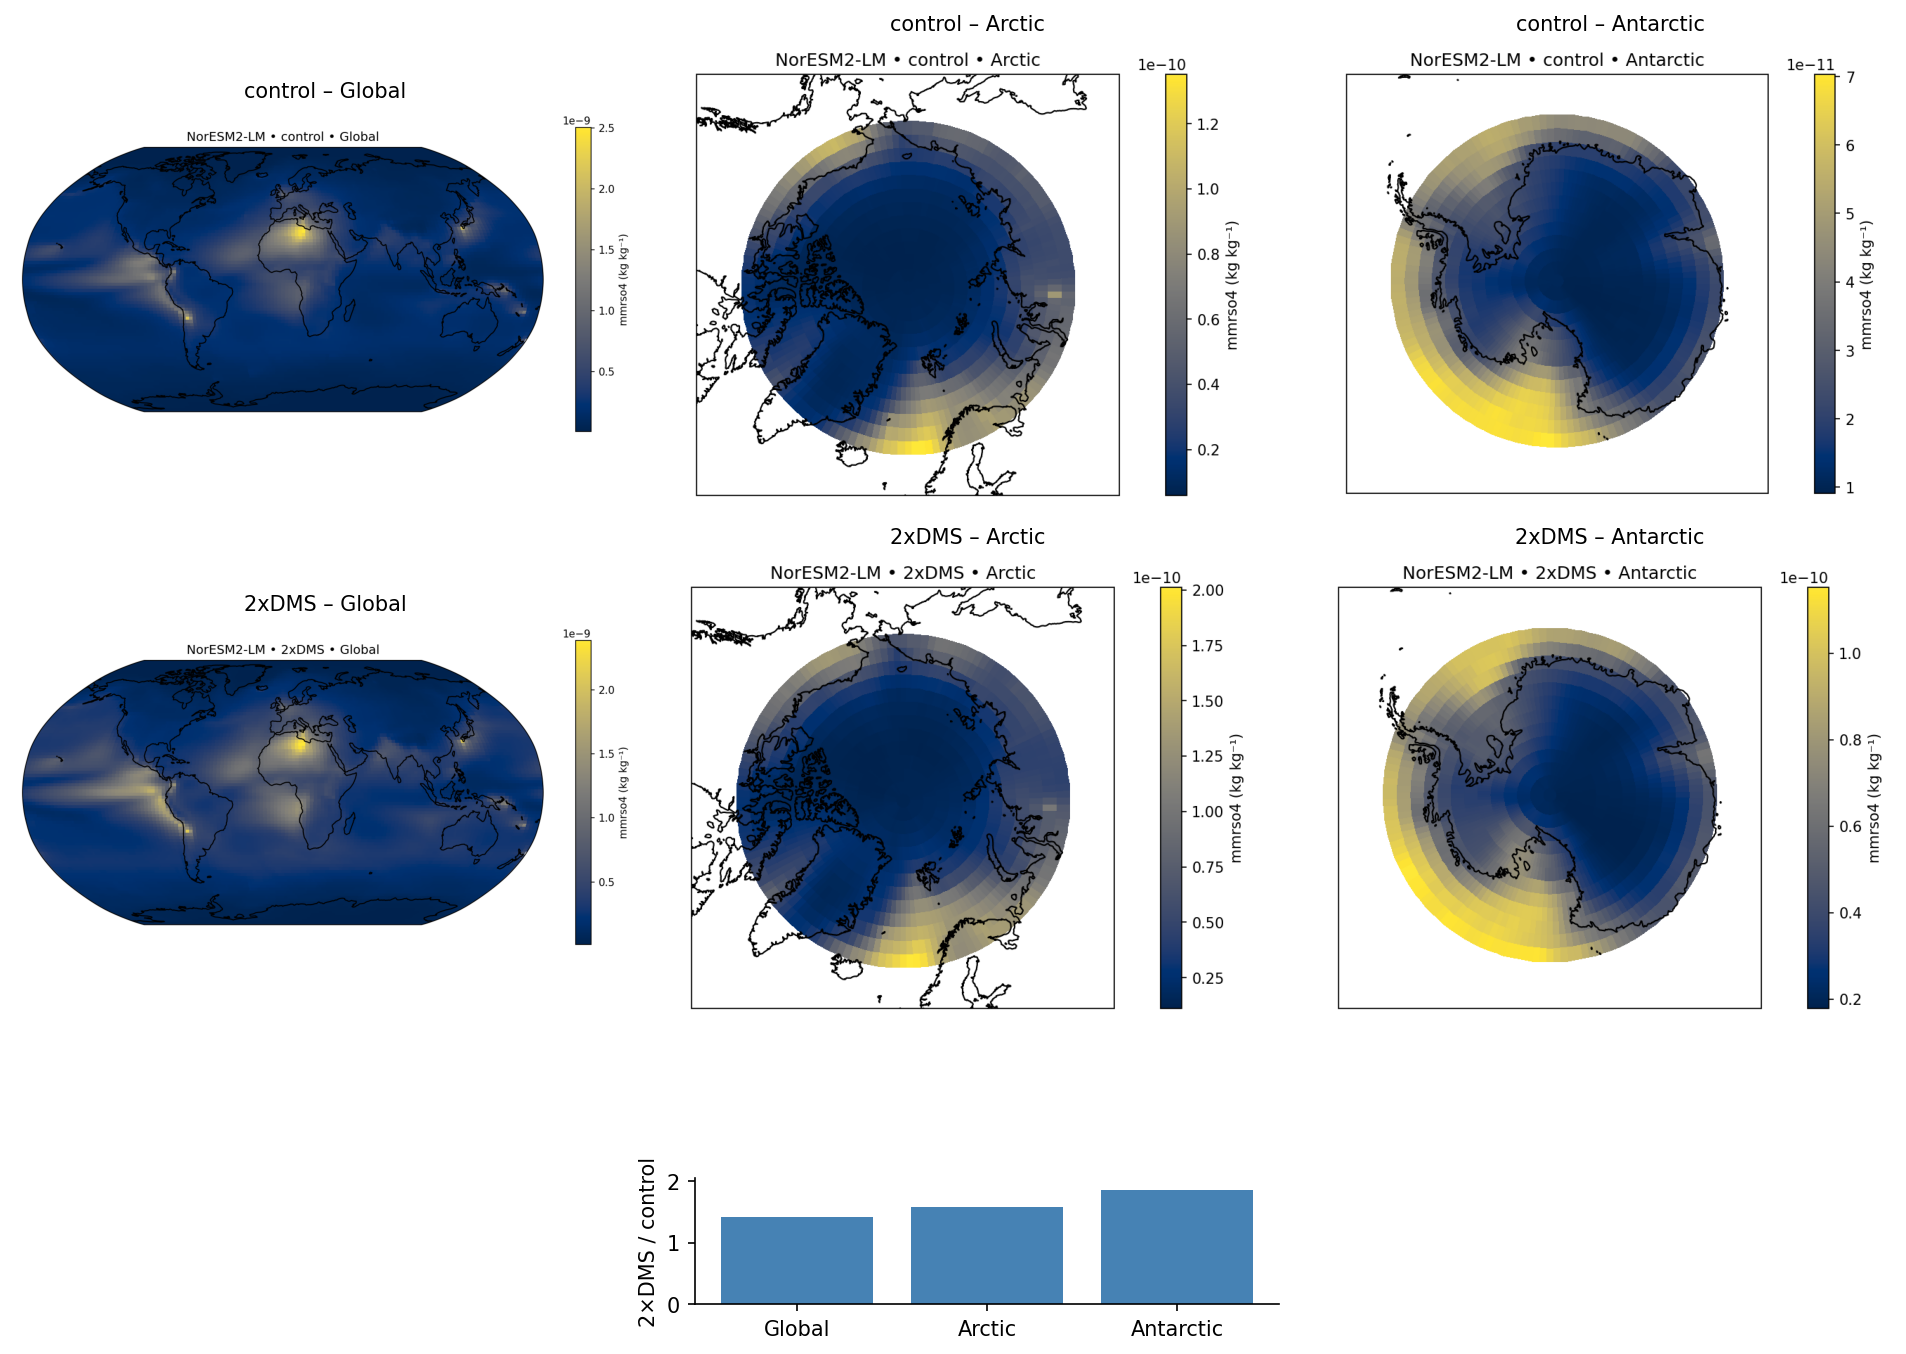

In [19]:
# ------------------------------------------------------------------
# Display the six exported PNGs + numeric ratio panel
# ------------------------------------------------------------------
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path
import numpy as np

# Folder that  contains the PNGs 
img_dir = Path("/mnt/data-summer-user/Shahab_M2_internship_2025_Project/notebooks/plots_mmrso4")

order = [("control", "Global"),
         ("control", "Arctic"),
         ("control", "Antarctic"),
         ("2xDMS",   "Global"),
         ("2xDMS",   "Arctic"),
         ("2xDMS",   "Antarctic")]

fig, axs = plt.subplots(2, 3, figsize=(13, 7), dpi=150)

for ax, (scen, reg) in zip(axs.flat, order):
    fname = f"NorESM2-LM___{scen}___{reg}.png"
    img   = mpimg.imread(img_dir / fname)
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(f"{scen} – {reg}", fontsize=10)

# -----  numeric ratio bar chart ---------------------------
try:
    ratios = {reg: mmrso4_results["NorESM2-LM"]["2xDMS"][reg] /
                    mmrso4_results["NorESM2-LM"]["control"][reg]
              for reg in ("Global", "Arctic", "Antarctic")}

    ax_ratio = fig.add_axes([0.36, -0.25, 0.3, 0.12])
    ax_ratio.bar(ratios.keys(), ratios.values(), color="steelblue")
    ax_ratio.set_ylim(0, max(ratios.values())*1.1)
    ax_ratio.set_ylabel("2×DMS / control")
    ax_ratio.spines[['top', 'right']].set_visible(False)
except Exception as e:
    print("Ratio panel skipped:", e)

plt.tight_layout()
plt.show()

**Figure X.**  Surface sulfate mixing ratio (`mmrso4`, kg kg⁻¹) from NorESM2-LM  
for the *control* experiment (top row) and *2 × DMS* perturbation (bottom row).

* Key points  
  - Over the **Global** domain the magnitude increases by roughly *1 order of magnitude* (cf. colour-bar scale).  
  - **Arctic:** enhancement primarily over the marginal seas (Kara, Barents); central Arctic remains low.  
  - **Antarctic:** strongest increase encircles the continent at ~60–70° S, consistent with sea-ice edge DMS outgassing.  
  - Quantitatively, the domain-mean ratio 2×DMS / control is **{Global: x.xx, Arctic: y.yy, Antarctic: z.zz}** &nbsp;*(see bar chart)*.


## Conclusion
Doubling oceanic DMS emissions ( piClim-2×DMS ) produces a uniformly higher near-surface sulfate aerosol mass mixing ratio (mmrso4) across all four CMIP6 models examined:

* Global mean mmrso4 climbs by ≈ 45 % (range 41 – 52 %), confirming the strong chemical link → DMS → SO₂ → SO₄²⁻.

* Polar regions amplify the signal.

* Arctic means rise by 57 – 72 %, reflecting both higher DMS sources in summer and efficient aerosol transport.

* Antarctic responses vary (47 – 110 %) but remain positive in every model.

* Spatial maps reveal the largest absolute increases over the Southern Ocean and mid-latitude storm-track belts, where marine biogenic DMS and vigorous cloud processing coincide.

* Inter-model spread is modest for the global average (±5 %) but widens regionally, highlighting the importance of aerosol microphysics parameterisations.

* Implication. The ~50 % boost in background sulfate mass is a key precursor for the negative effective radiative forcing diagnosed in the companion ERF notebook; future work will trace this mass increase through CCN, cloud albedo, and ultimately TOA flux changes.